In [1]:
!pip install opendatasets --quiet
import opendatasets as od
kaggleURL = "https://www.kaggle.com/datasets/"
od.download(kaggleURL + "masoudnickparvar/brain-tumor-mri-dataset")

Skipping, found downloaded files in "./brain-tumor-mri-dataset" (use force=True to force download)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment as linear_assignment # For newer scikit-learn

In [3]:
# --- Configuration ---
ROOT_DATA_DIR = 'brain-tumor-mri-dataset' # Already defined
TRAIN_DATA_DIR = os.path.join(ROOT_DATA_DIR, 'Training') # Already defined
TEST_DATA_DIR = os.path.join(ROOT_DATA_DIR, 'Testing') # Already defined
IMAGE_SIZE = 128 # Already defined
BATCH_SIZE = 32 # Already defined
NUM_CLASSES = 4 # Already defined

LEARNING_RATE_UNSUPERVISED = 0.001
NUM_EPOCHS_UNSUPERVISED = 30 # Autoencoders often need more epochs
LATENT_DIM = 64 # Size of the learned representation

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"I am on {device}")

I am on cuda


In [5]:
unsupervised_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [8]:
# Load training and testing datasets
train_ae_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR, transform=unsupervised_transform)
test_ae_dataset = datasets.ImageFolder(root=TEST_DATA_DIR, transform=unsupervised_transform)

In [9]:
# Combine them for unsupervised training
full_unsupervised_dataset = ConcatDataset([train_ae_dataset, test_ae_dataset])
unsupervised_loader = DataLoader(full_unsupervised_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [10]:
# Get class names from one of the ImageFolder instances (they should be the same)
class_names_ae = train_ae_dataset.classes
all_labels_true = np.array([label for _, label in full_unsupervised_dataset]) # Keep true labels for evaluation later

In [11]:
print(f"\nUnsupervised Samples (combined): {len(full_unsupervised_dataset)}")
print(f"Classes for reference: {class_names_ae}")


Unsupervised Samples (combined): 7023
Classes for reference: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [12]:
# --- Unsupervised Model Definition (Convolutional Autoencoder) ---
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 16x64x64
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 64x16x16
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), latent_dim) # Latent space
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8)),
            nn.ReLU(),
            nn.Unflatten(1, (64, IMAGE_SIZE // 8, IMAGE_SIZE // 8)), # Reshape to 64x16x16
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 32x32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # 16x64x64
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # 1x128x128
            nn.Tanh() # Output pixel values in range [-1, 1] after normalization
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent

In [13]:
# --- Training Function for Autoencoder ---
def train_unsupervised_model(model, data_loader, criterion, optimizer, num_epochs):
    losses = []
    print("\n--- Starting Unsupervised (Autoencoder) Training ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, _ in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} (AE Train)"):
            images = images.to(device)

            optimizer.zero_grad()
            reconstructions, _ = model(images)
            loss = criterion(reconstructions, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(data_loader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Avg Reconstruction Loss: {avg_loss:.4f}")
    print("\n--- Unsupervised Training Complete ---")
    return losses

In [14]:
# --- Run Unsupervised Learning ---
unsupervised_model = ConvAutoencoder(latent_dim=LATENT_DIM).to(device)
criterion_unsupervised = nn.MSELoss() # Reconstruction loss
optimizer_unsupervised = optim.Adam(unsupervised_model.parameters(), lr=LEARNING_RATE_UNSUPERVISED)

ae_losses = train_unsupervised_model(
    unsupervised_model, unsupervised_loader,
    criterion_unsupervised, optimizer_unsupervised, NUM_EPOCHS_UNSUPERVISED
)


--- Starting Unsupervised (Autoencoder) Training ---


Epoch 1/30 (AE Train): 100%|██████████████████████████████████████████████████████████| 220/220 [02:03<00:00,  1.78it/s]


Epoch [1/30], Avg Reconstruction Loss: 0.0893


Epoch 2/30 (AE Train): 100%|██████████████████████████████████████████████████████████| 220/220 [00:13<00:00, 15.74it/s]


Epoch [2/30], Avg Reconstruction Loss: 0.0522


...

Epoch [28/30], Avg Reconstruction Loss: 0.0156


Epoch 29/30 (AE Train): 100%|█████████████████████████████████████████████████████████| 220/220 [00:14<00:00, 15.26it/s]


Epoch [29/30], Avg Reconstruction Loss: 0.0154


Epoch 30/30 (AE Train): 100%|█████████████████████████████████████████████████████████| 220/220 [00:16<00:00, 13.48it/s]

Epoch [30/30], Avg Reconstruction Loss: 0.0153

--- Unsupervised Training Complete ---


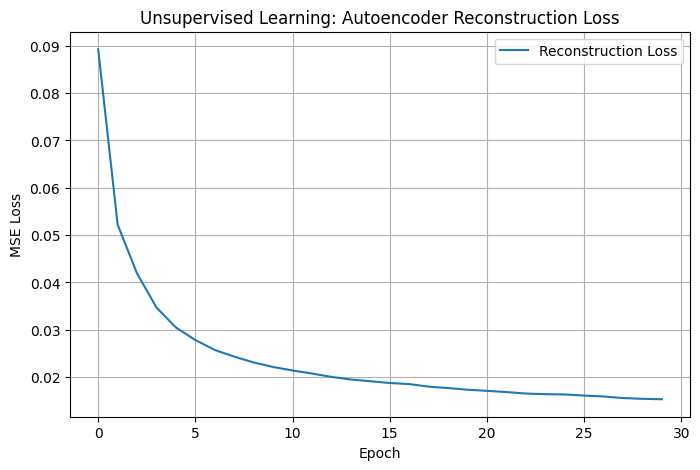

In [15]:
# --- Plotting Autoencoder Reconstruction Loss ---
plt.figure(figsize=(8, 5))
plt.plot(ae_losses, label='Reconstruction Loss')
plt.title('Unsupervised Learning: Autoencoder Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

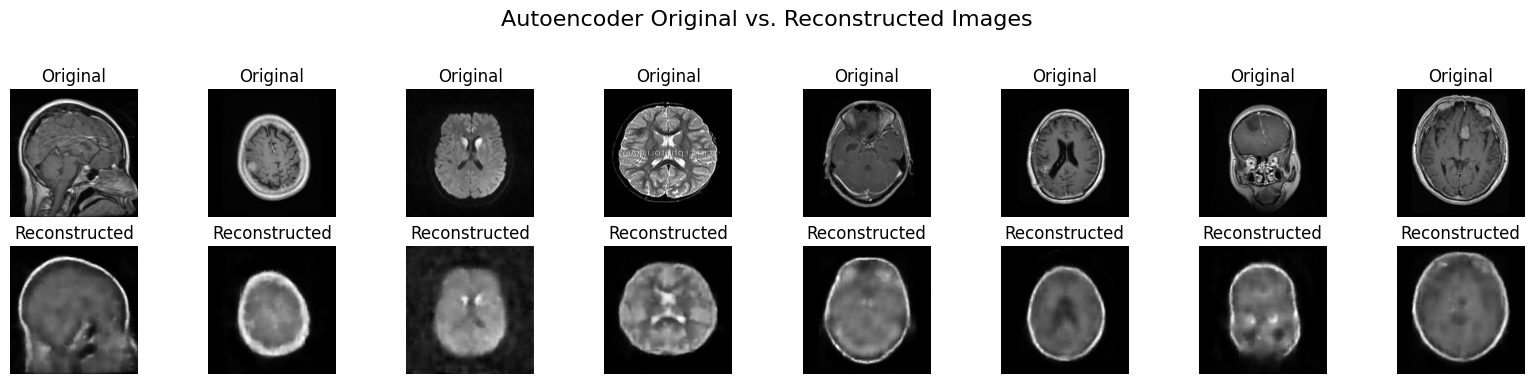

In [16]:
# --- Visualize Reconstructions ---
unsupervised_model.eval()
with torch.no_grad():
    dataiter = iter(unsupervised_loader)
    images, _ = next(dataiter)
    images = images[:8].to(device) # Take first 8 images
    reconstructions, _ = unsupervised_model(images)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        # Original
        ax = axes[0, i]
        img = images[i].cpu().numpy().squeeze()
        # Denormalize for display [-1, 1] -> [0, 1]
        img = (img * 0.5) + 0.5
        ax.imshow(img, cmap='gray')
        ax.set_title("Original")
        ax.axis('off')

        # Reconstructed
        ax = axes[1, i]
        img_rec = reconstructions[i].cpu().numpy().squeeze()
        # Denormalize for display [-1, 1] -> [0, 1]
        img_rec = (img_rec * 0.5) + 0.5
        ax.imshow(img_rec, cmap='gray')
        ax.set_title("Reconstructed")
        ax.axis('off')
    plt.suptitle('Autoencoder Original vs. Reconstructed Images', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [17]:
# --- Extract Latent Features and Perform K-Means Clustering ---
print("\n--- Extracting Latent Features for Clustering ---")
unsupervised_model.eval()
all_latent_features = []
with torch.no_grad():
    for images, _ in tqdm(unsupervised_loader, desc="Extracting features"):
        images = images.to(device)
        _, latent = unsupervised_model(images)
        all_latent_features.append(latent.cpu().numpy())

all_latent_features = np.vstack(all_latent_features)


--- Extracting Latent Features for Clustering ---


Extracting features: 100%|████████████████████████████████████████████████████████████| 220/220 [00:14<00:00, 14.67it/s]


In [18]:
# Apply K-Means clustering (we know there are NUM_CLASSES true classes)
kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=42, n_init=10) # n_init for robust centroid initialization
clusters = kmeans.fit_predict(all_latent_features)

In [19]:
# --- Evaluate Clustering against True Labels ---
def get_best_cluster_mapping(clusters, true_labels, num_classes):
    # Create a contingency matrix (confusion matrix between true labels and cluster assignments)
    # Rows are true_labels, columns are cluster_ids
    contingency_matrix = np.zeros((num_classes, num_classes), dtype=int)
    for i in range(len(clusters)):
        contingency_matrix[true_labels[i]][clusters[i]] += 1

    # Apply Hungarian algorithm to find the best mapping
    # We want to maximize the sum of elements along the chosen permutation, so we minimize negative counts
    row_ind, col_ind = linear_assignment(-contingency_matrix)

    mapping = np.zeros(num_classes, dtype=int)
    for r, c in zip(row_ind, col_ind):
        mapping[c] = r # cluster_id -> true_label_id

    return mapping

In [20]:
# Map clusters to true labels (0, 1, 2, 3)
mapping = get_best_cluster_mapping(clusters, all_labels_true, NUM_CLASSES)
predicted_labels_mapped = np.array([mapping[cluster_id] for cluster_id in clusters])

In [21]:
# Calculate Clustering Metrics
ari_score = adjusted_rand_score(all_labels_true, clusters) # Compares clusterings directly
nmi_score = normalized_mutual_info_score(all_labels_true, clusters) # Measures mutual info between cluster and true labels

In [22]:
print(f"\nUnsupervised Clustering Results (based on {NUM_CLASSES} clusters):")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}") # Higher is better, 1.0 is perfect
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}") # Higher is better, 1.0 is perfect


Unsupervised Clustering Results (based on 4 clusters):
Adjusted Rand Index (ARI): -0.0003
Normalized Mutual Information (NMI): 0.0004



--- Generating t-SNE plot (this might take a moment) ---


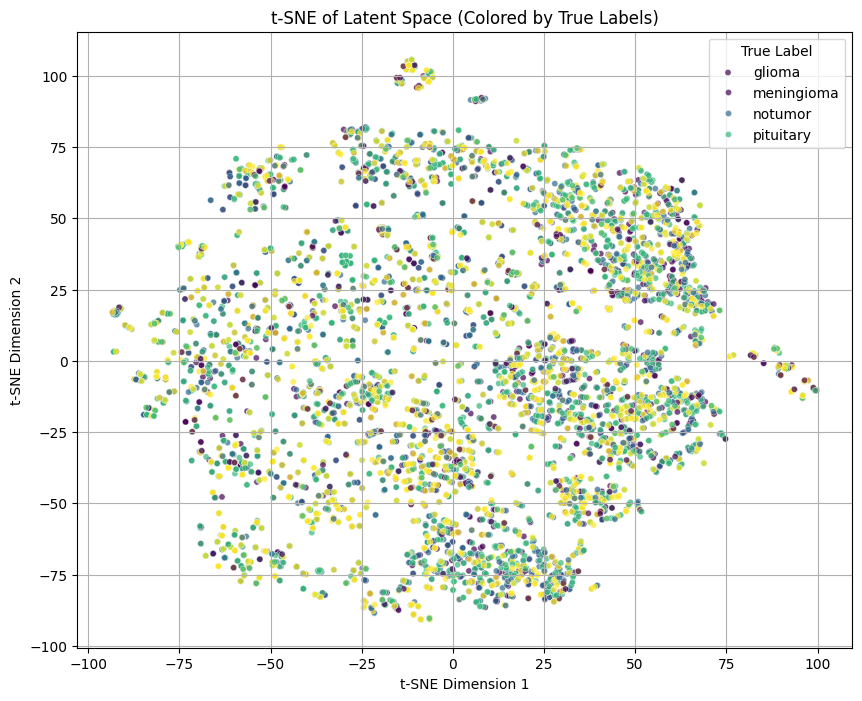

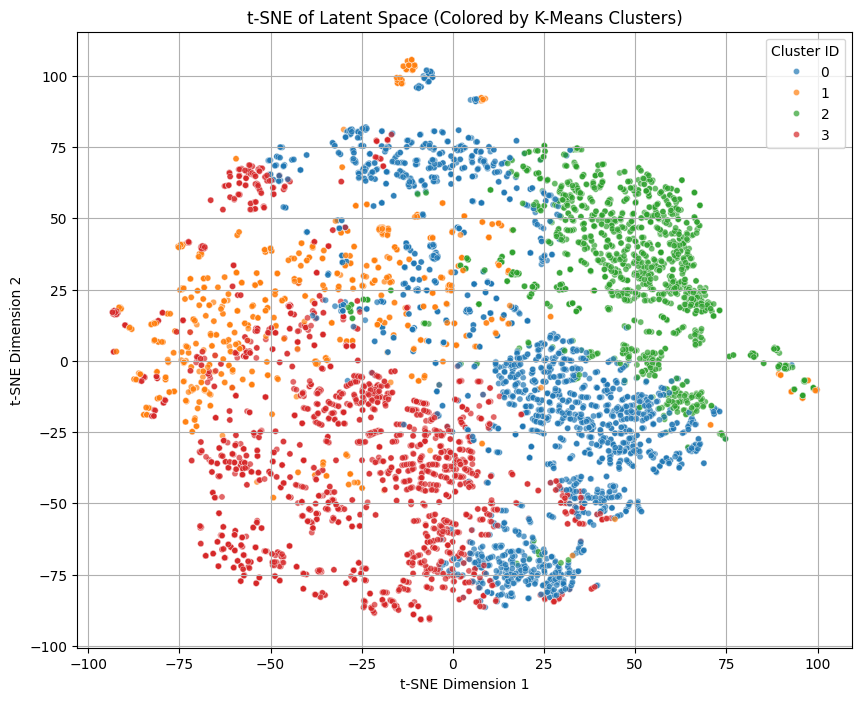

In [25]:
# --- Plotting Clustering Results ---
# 1. t-SNE visualization of latent space
print("\n--- Generating t-SNE plot (this might take a moment) ---")
# FIX: Changed n_iter to max_iter
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
latent_2d = tsne.fit_transform(all_latent_features)

plt.figure(figsize=(10, 8))
# Plot colored by TRUE labels
sns.scatterplot(
    x=latent_2d[:, 0], y=latent_2d[:, 1],
    hue=all_labels_true, palette='viridis', legend='full',
    alpha=0.7, s=20
)
plt.title('t-SNE of Latent Space (Colored by True Labels)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='True Label', labels=class_names_ae) # Use actual class names
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
# Plot colored by K-Means CLUSTERS
sns.scatterplot(
    x=latent_2d[:, 0], y=latent_2d[:, 1],
    hue=clusters, palette='tab10', legend='full',
    alpha=0.7, s=20
)
plt.title('t-SNE of Latent Space (Colored by K-Means Clusters)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()


--- Unsupervised Clustering Confusion Matrix ---


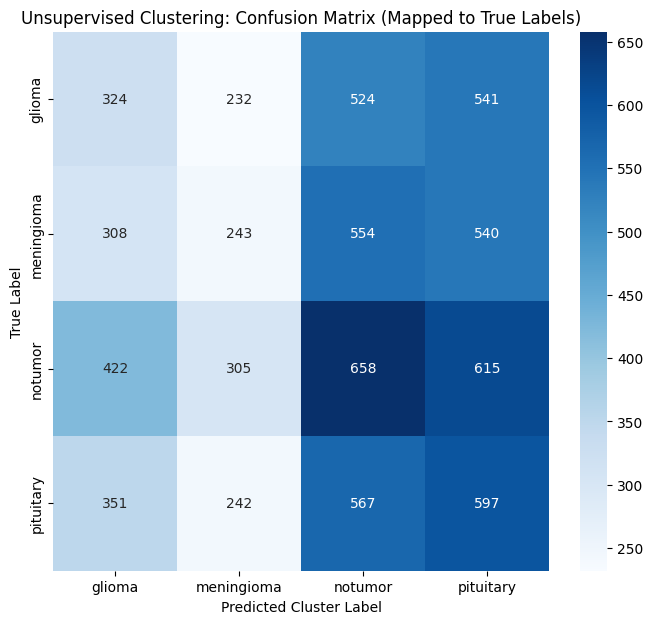

In [26]:
# 2. Confusion Matrix of K-Means Clusters vs True Labels (after best mapping)
print("\n--- Unsupervised Clustering Confusion Matrix ---")
unsupervised_cm = confusion_matrix(all_labels_true, predicted_labels_mapped)
plt.figure(figsize=(8, 7)) # Adjust size for 4x4 matrix
sns.heatmap(unsupervised_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_ae, yticklabels=class_names_ae)
plt.title('Unsupervised Clustering: Confusion Matrix (Mapped to True Labels)')
plt.xlabel('Predicted Cluster Label')
plt.ylabel('True Label')
plt.show()